In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

conn = sqlite3.connect('../data/saas_analytics.db')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                  name
0                users
1                forms
2        subscriptions
3               events
4          submissions
5  ab_test_assignments
6      support_tickets
7      marketing_spend


In [2]:
users = pd.read_sql("SELECT * FROM users", conn)

print("Boyut (satır, sütun):", users.shape)
print()
users.info()

Boyut (satır, sütun): (120000, 10)

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   user_id              120000 non-null  int64
 1   signup_date          120000 non-null  str  
 2   acquisition_channel  120000 non-null  str  
 3   utm_source           120000 non-null  str  
 4   company_size         120000 non-null  str  
 5   country              120000 non-null  str  
 6   browser              120000 non-null  str  
 7   operating_system     120000 non-null  str  
 8   email_domain         120000 non-null  str  
 9   is_email_verified    120000 non-null  int64
dtypes: int64(2), str(8)
memory usage: 9.2 MB


In [5]:
#Sentetik bir veri olduğu için null değerler yok

In [3]:
users.describe()

,user_id,is_email_verified
count,120000.000000,120000.000000
mean,60000.500000,0.879792
std,34641.160489,0.325206
min,1.000000,0.000000
25%,30000.750000,1.000000
50%,60000.500000,1.000000
75%,90000.250000,1.000000
max,120000.000000,1.000000


In [6]:
#signup_date string olarak gözüküyor, bunları date time fonksiyonuna çevirdim çünkü tarih üzerinde işlem yapmak (ay çıkarmak, gün farkı hesaplamak, filtrelemek) istediğimde string olarak kalırsa hata alırım ya da yanlış sonuç çıkar

In [7]:
users['signup_date'] = pd.to_datetime(users['signup_date'])
print("signup_date yeni tipi:", users['signup_date'].dtype)
print()

signup_date yeni tipi: datetime64[us]



In [8]:
#is_email_verified sütunu boolean olması gerekir (1/2) String gereksiz yer kaplar !

In [9]:
users['is_email_verified'] = users['is_email_verified'].astype(bool)
print("is_email_verified yeni tipi:", users['is_email_verified'].dtype)
print()

is_email_verified yeni tipi: bool



In [10]:
#Tekrar eden ID ler var mı kontrolü yapmamız lazım, bu user tablosu ve her ID'nin benzersiz olmasını isteriz

In [11]:
print("Tekrar eden user_id sayısı:", users['user_id'].duplicated().sum())
print()

Tekrar eden user_id sayısı: 0



In [12]:
for col in ['acquisition_channel', 'company_size', 'country', 'browser', 'operating_system']:
    print(f"--- {col} ---")
    print(users[col].value_counts())
    print()

--- acquisition_channel ---
acquisition_channel
organic_search       35893
paid_search          26411
paid_social          24037
content_marketing    18072
referral             15587
Name: count, dtype: int64

--- company_size ---
company_size
solo          53874
small_team    36083
smb           21602
enterprise     8441
Name: count, dtype: int64

--- country ---
country
US    42142
UK    11973
IN    10729
DE     9618
TR     9534
CA     8405
FR     7203
BR     7176
NL     7170
AU     6050
Name: count, dtype: int64

--- browser ---
browser
Chrome     65882
Safari     24081
Edge       11989
Firefox    11962
Other       6086
Name: count, dtype: int64

--- operating_system ---
operating_system
Windows    50634
macOS      26296
Android    18999
iOS        17966
Linux       6105
Name: count, dtype: int64



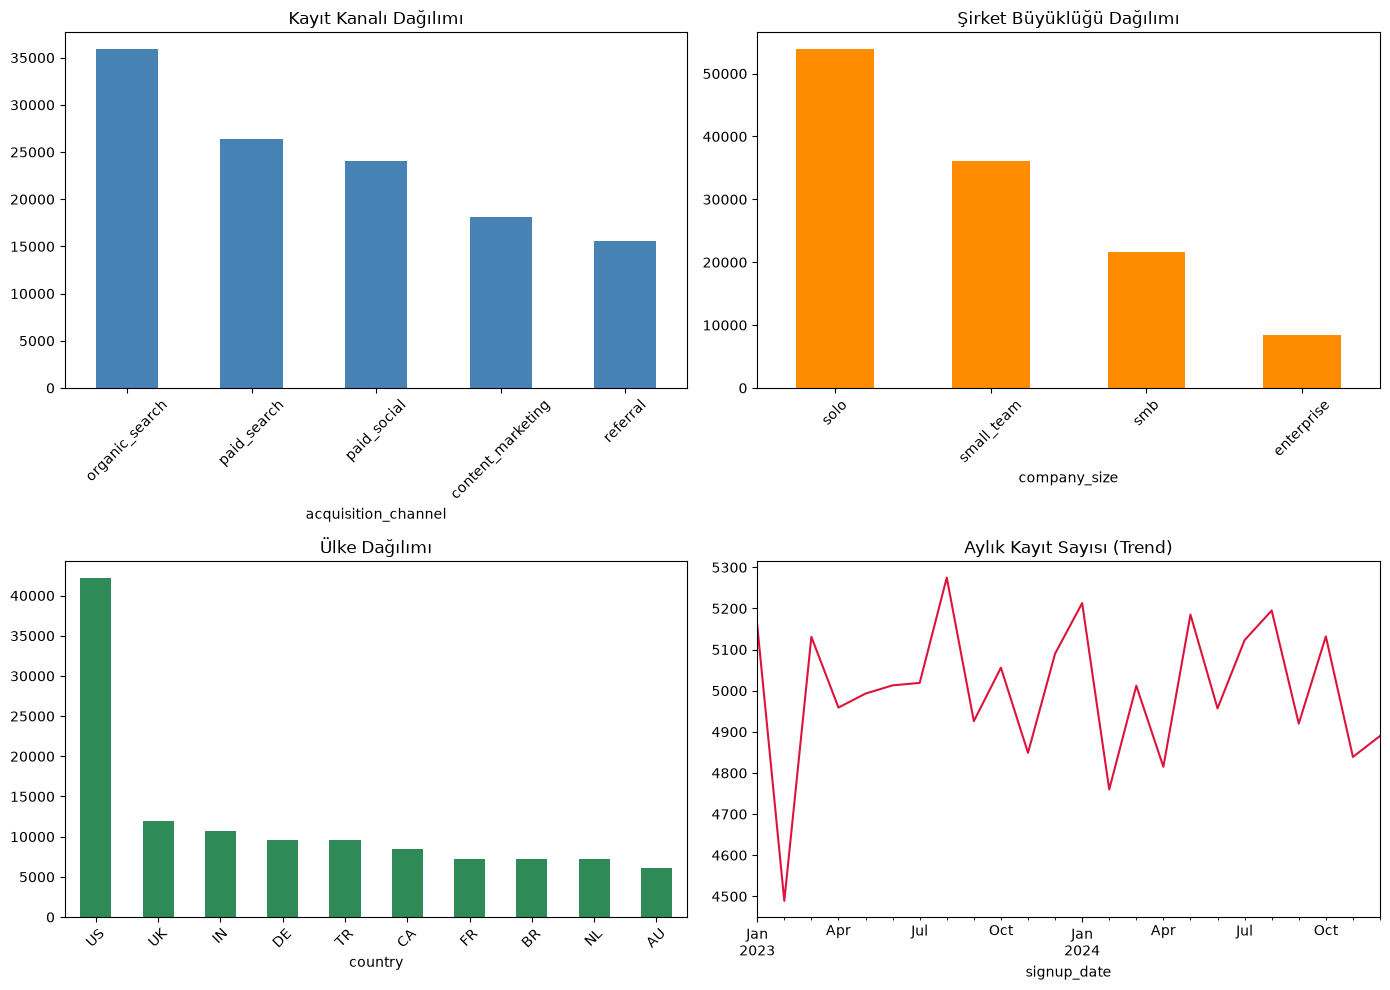

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

users['acquisition_channel'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Kayıt Kanalı Dağılımı')
axes[0,0].tick_params(axis='x', rotation=45)

users['company_size'].value_counts().plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Şirket Büyüklüğü Dağılımı')
axes[0,1].tick_params(axis='x', rotation=45)

users['country'].value_counts().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Ülke Dağılımı')
axes[1,0].tick_params(axis='x', rotation=45)

# Zaman icinde kayit trendi
users.set_index('signup_date').resample('ME').size().plot(ax=axes[1,1], color='crimson')
axes[1,1].set_title('Aylık Kayıt Sayısı (Trend)')

plt.tight_layout()
plt.show()

In [14]:
#Aylık Kayıt Sayısındaki dalgalanmaların sebebi ayların uzunlukları olabilir, Örneğin grafikte şubat ayının kayıt sayısı diğer aylara göre çok düşük.
#Ancak bunu varsaymak doğru olmaz, doğrulama yapacağız

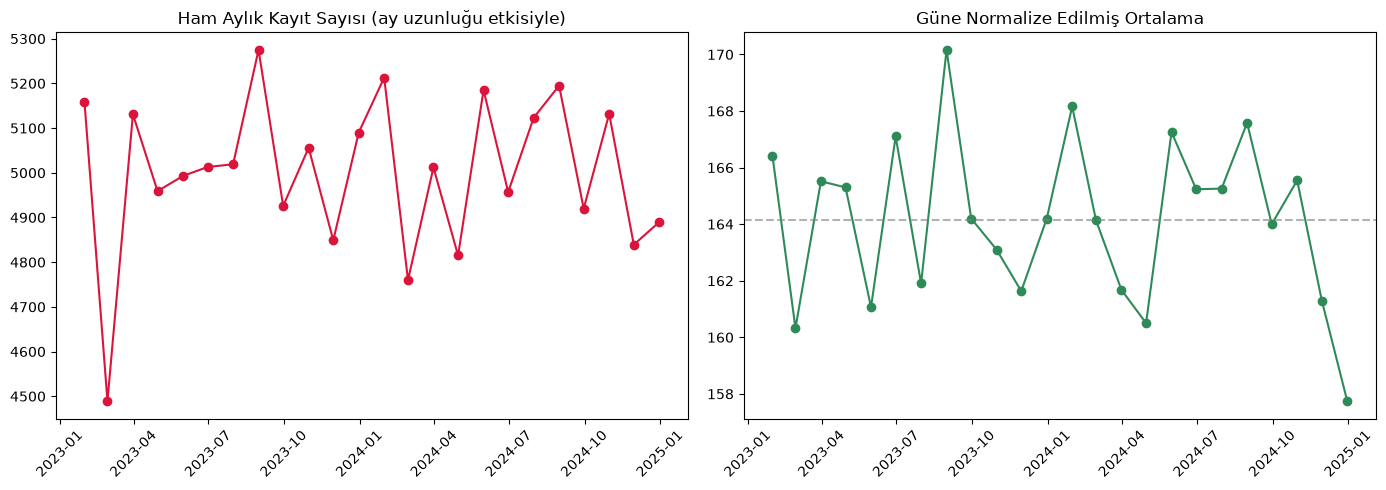

In [16]:
monthly = users.set_index('signup_date').resample('ME').size()
monthly_df = monthly.reset_index()
monthly_df.columns = ['month_end', 'signups']
monthly_df['days_in_month'] = monthly_df['month_end'].dt.days_in_month
monthly_df['avg_daily_signups'] = monthly_df['signups'] / monthly_df['days_in_month']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(monthly_df['month_end'], monthly_df['signups'], marker='o', color='crimson')
axes[0].set_title('Ham Aylık Kayıt Sayısı (ay uzunluğu etkisiyle)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_df['month_end'], monthly_df['avg_daily_signups'], marker='o', color='seagreen')
axes[1].set_title('Güne Normalize Edilmiş Ortalama')
axes[1].axhline(monthly_df['avg_daily_signups'].mean(), color='gray', linestyle='--', alpha=0.6)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

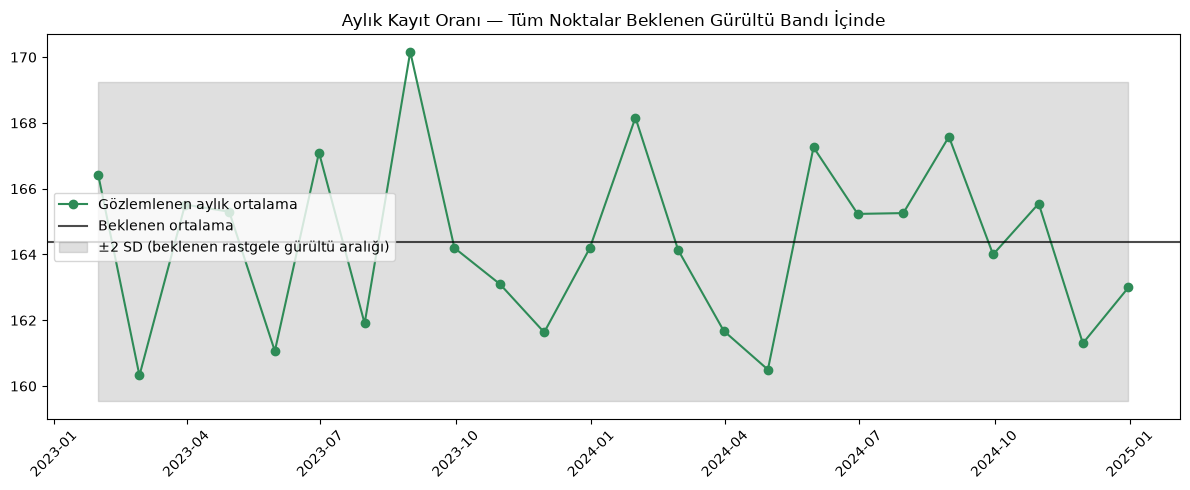

In [17]:
daily = users.set_index('signup_date').resample('D').size()
expected_rate = daily.mean()
theoretical_sd = np.sqrt(expected_rate)

monthly_avg = daily.resample('ME').mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='seagreen', label='Gözlemlenen aylık ortalama')
plt.axhline(expected_rate, color='black', linestyle='-', alpha=0.7, label='Beklenen ortalama')
plt.fill_between(monthly_avg.index,
                  expected_rate - 2*theoretical_sd/np.sqrt(28),
                  expected_rate + 2*theoretical_sd/np.sqrt(28),
                  color='gray', alpha=0.25, label='±2 SD (beklenen rastgele gürültü aralığı)')
plt.title('Aylık Kayıt Oranı — Tüm Noktalar Beklenen Gürültü Bandı İçinde')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
#Bu sonuca göre aylık kayıt trendinde görünen dalgalanma, örneklem büyüklüğünden kaynaklanan beklenen rastgele gürültüdür, sistematik bir trend değildir

In [19]:
forms = pd.read_sql("SELECT * FROM forms", conn)

print("Boyut (satır, sütun):", forms.shape)
print()
forms.info()

Boyut (satır, sütun): (250624, 10)

<class 'pandas.DataFrame'>
RangeIndex: 250624 entries, 0 to 250623
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   form_id            250624 non-null  int64
 1   user_id            250624 non-null  int64
 2   created_at         250624 non-null  str  
 3   category           250624 non-null  str  
 4   form_name          250624 non-null  str  
 5   field_count        250624 non-null  int64
 6   language           250624 non-null  str  
 7   has_payment_field  250624 non-null  int64
 8   integration_count  250624 non-null  int64
 9   is_published       250624 non-null  int64
dtypes: int64(6), str(4)
memory usage: 19.1 MB


In [22]:
# Tip duzeltmeleri
forms['created_at'] = pd.to_datetime(forms['created_at'])
forms['has_payment_field'] = forms['has_payment_field'].astype(bool)
forms['is_published'] = forms['is_published'].astype(bool)

In [21]:
# Duplicate kontrolü
print("Tekrar eden form_id sayısı:", forms['form_id'].duplicated().sum())
print()

Tekrar eden form_id sayısı: 0



In [23]:
#Sayısal Sütun dağılımı
print(forms['field_count'].describe())
print()

count    250624.000000
mean          6.539282
std           2.919487
min           1.000000
25%           4.000000
50%           7.000000
75%           9.000000
max          19.000000
Name: field_count, dtype: float64



In [24]:
#Kategori Dağılımı
print(forms['category'].value_counts())
print()

category
contact_form       70195
survey             45141
registration       30066
feedback           29925
payment_form       25404
order_form         24911
other              12502
job_application    12480
Name: count, dtype: int64



In [25]:
#Mantıksal Tutarlılık kontrolü; Örneğin bir form user'ın kayıt tarihinden önce oluşturulamaz
check = forms.merge(users[['user_id', 'signup_date']], on='user_id')
invalid_forms = check[check['created_at'] < check['signup_date']]
print(f"Kayittan ONCE olusturulmus gorunen form sayisi: {len(invalid_forms)}")

Kayittan ONCE olusturulmus gorunen form sayisi: 0


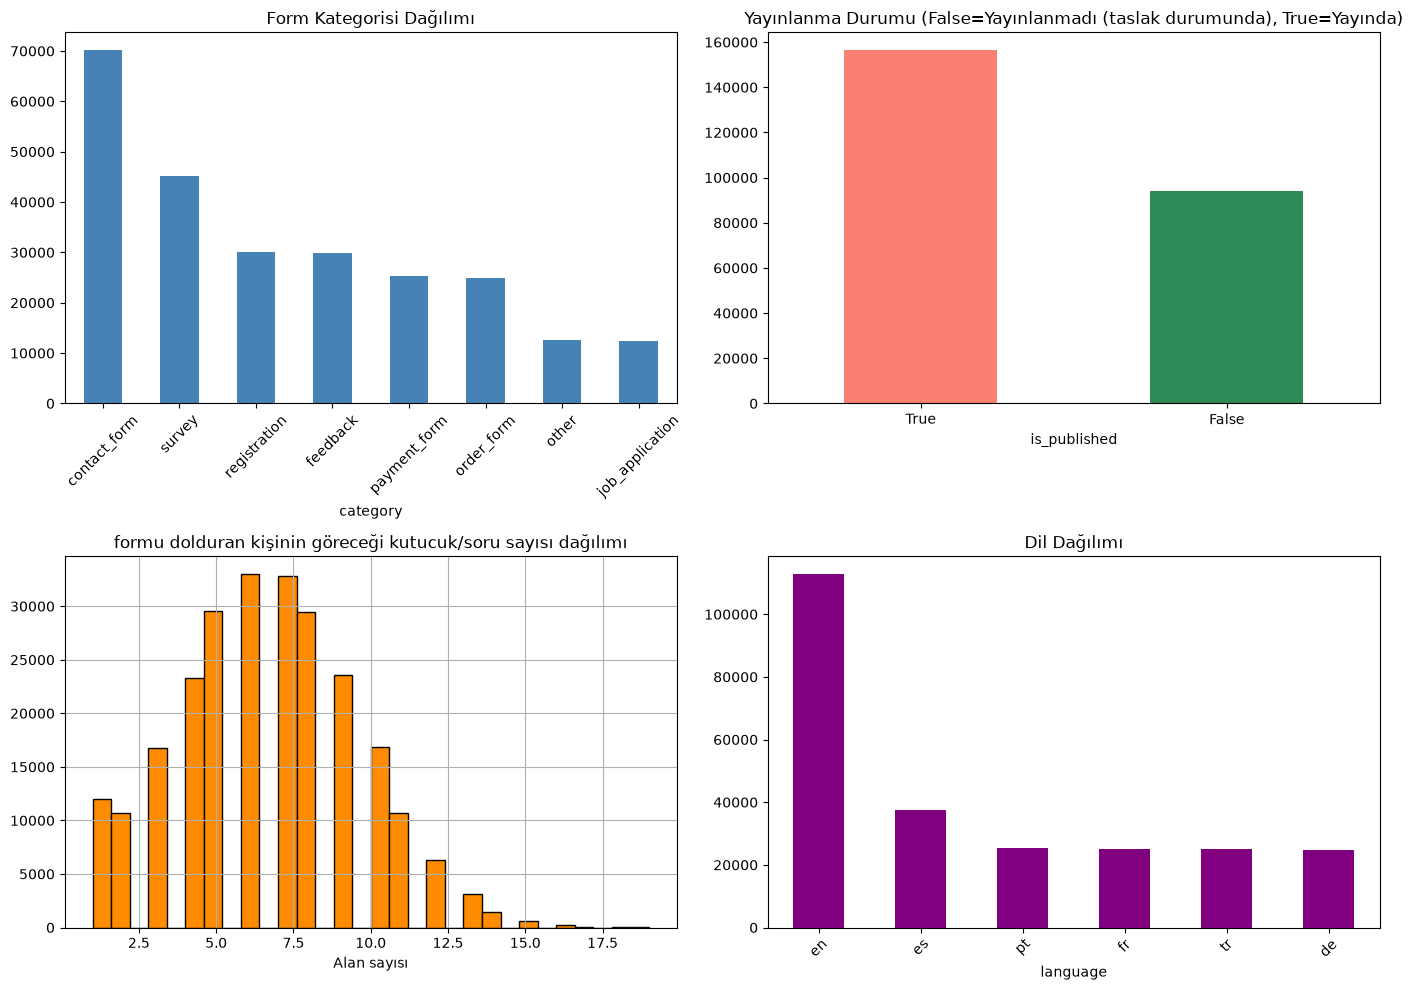

Genel yayınlanma oranı: %62.4


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

forms['category'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Form Kategorisi Dağılımı')
axes[0,0].tick_params(axis='x', rotation=45)

forms['is_published'].value_counts().plot(kind='bar', ax=axes[0,1], color=['salmon','seagreen'])
axes[0,1].set_title('Yayınlanma Durumu (False=Yayınlanmadı (taslak durumunda), True=Yayında)')
axes[0,1].tick_params(axis='x', rotation=0)

forms['field_count'].hist(bins=30, ax=axes[1,0], color='darkorange', edgecolor='black')
axes[1,0].set_title('formu dolduran kişinin göreceği kutucuk/soru sayısı dağılımı')
axes[1,0].set_xlabel('Alan sayısı')

forms['language'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Dil Dağılımı')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Genel yayınlanma oranı: %{100*forms['is_published'].mean():.1f}")

In [29]:
subscriptions = pd.read_sql("SELECT * FROM subscriptions", conn)

print("Boyut (satır, sütun):", subscriptions.shape)
print()
subscriptions.info()

Boyut (satır, sütun): (120000, 8)

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   user_id         120000 non-null  int64
 1   plan            120000 non-null  str  
 2   mrr             120000 non-null  int64
 3   billing_cycle   120000 non-null  str  
 4   payment_method  120000 non-null  str  
 5   start_date      120000 non-null  str  
 6   is_churned      120000 non-null  int64
 7   churn_date      3259 non-null    str  
dtypes: int64(3), str(5)
memory usage: 7.3 MB


In [30]:
#churn_date sütununda yalnızca 3259 null olmayan değerler var, ancak bu bir hata değil. Bize churn olan 3259 kişinin var olduğunu söylüyor.

In [31]:
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['churn_date'] = pd.to_datetime(subscriptions['churn_date'])
subscriptions['is_churned'] = subscriptions['is_churned'].astype(bool)

In [32]:
#Tutarlılık kontrolü
# churn_date dolu olan satır sayısıyla birebir eşleşmeli
print("is_churned=True olan satır sayısı:", subscriptions['is_churned'].sum())
print("churn_date dolu olan satır sayısı:", subscriptions['churn_date'].notna().sum())
print("İkisi eşleşiyor mu?", subscriptions['is_churned'].sum() == subscriptions['churn_date'].notna().sum())
print()

is_churned=True olan satır sayısı: 3259
churn_date dolu olan satır sayısı: 3259
İkisi eşleşiyor mu? True



In [33]:
print("Tekrar eden user_id sayısı:", subscriptions['user_id'].duplicated().sum())
print()

Tekrar eden user_id sayısı: 0



In [34]:
for col in ['plan', 'billing_cycle', 'payment_method']:
    print(f"--- {col} ---")
    print(subscriptions[col].value_counts())
    print()

--- plan ---
plan
free      102993
bronze      8540
silver      5909
gold        2558
Name: count, dtype: int64

--- billing_cycle ---
billing_cycle
monthly    114789
annual       5211
Name: count, dtype: int64

--- payment_method ---
payment_method
credit_card      89995
paypal           21511
bank_transfer     8494
Name: count, dtype: int64



In [35]:
print("MRR describe (sadece plan != free):")
print(subscriptions[subscriptions['plan'] != 'free']['mrr'].describe())

MRR describe (sadece plan != free):
count    17007.000000
mean        24.978127
std         11.933860
min         15.000000
25%         15.000000
50%         15.000000
75%         29.000000
max         49.000000
Name: mrr, dtype: float64


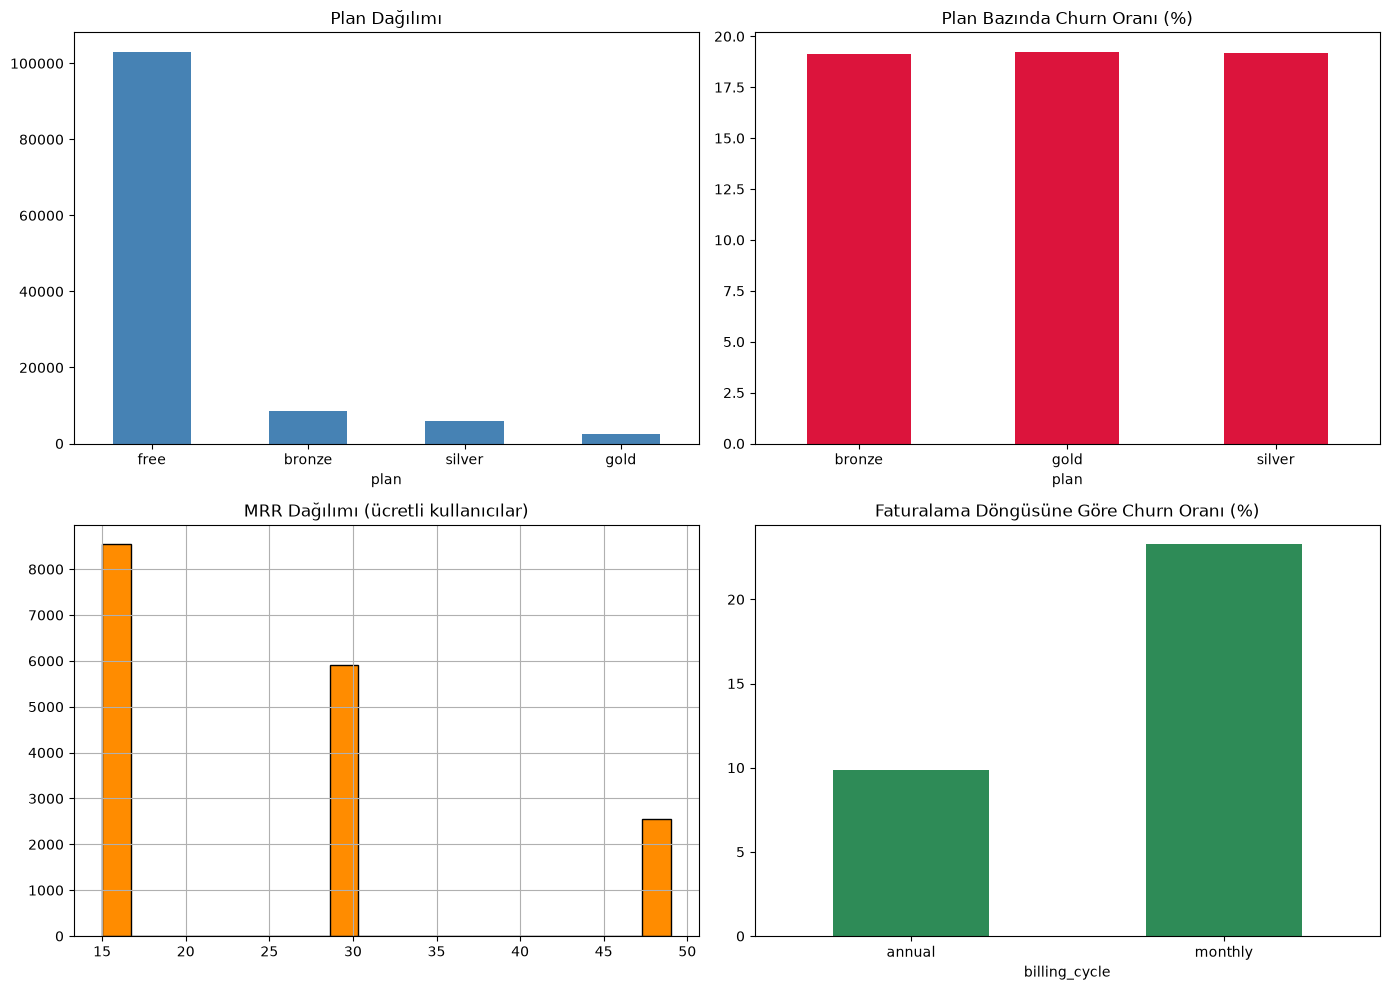

Genel ücretli kullanıcı churn oranı: %19.2
Ücretsiz (free) kullanıcı oranı: %85.8


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

subscriptions['plan'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Plan Dağılımı')
axes[0,0].tick_params(axis='x', rotation=0)

churn_by_plan = subscriptions[subscriptions['plan'] != 'free'].groupby('plan')['is_churned'].mean() * 100
churn_by_plan.plot(kind='bar', ax=axes[0,1], color='crimson')
axes[0,1].set_title('Plan Bazında Churn Oranı (%)')
axes[0,1].tick_params(axis='x', rotation=0)

subscriptions[subscriptions['plan'] != 'free']['mrr'].hist(bins=20, ax=axes[1,0], color='darkorange', edgecolor='black')
axes[1,0].set_title('MRR Dağılımı (ücretli kullanıcılar)')

churn_by_billing = subscriptions[subscriptions['plan'] != 'free'].groupby('billing_cycle')['is_churned'].mean() * 100
churn_by_billing.plot(kind='bar', ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Faturalama Döngüsüne Göre Churn Oranı (%)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Genel ücretli kullanıcı churn oranı: %{100*subscriptions[subscriptions['plan']!='free']['is_churned'].mean():.1f}")
print(f"Ücretsiz (free) kullanıcı oranı: %{100*(subscriptions['plan']=='free').mean():.1f}")

In [38]:
#Yıllık faturalandırmayı seçenler çok daha az churn ediyor. Sadakatin faturalama sıklığından kaynaklanan bir davranışsal etki olabilir ancak tersi bir etkide olabilir yani belki de sadık kalacak kişiler zaten yıllık planı seçiyor.

In [39]:
events = pd.read_sql("SELECT * FROM events", conn)

print("Boyut (satır, sütun):", events.shape)
print()
events.info()

Boyut (satır, sütun): (959714, 5)

<class 'pandas.DataFrame'>
RangeIndex: 959714 entries, 0 to 959713
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   event_id    959714 non-null  int64
 1   user_id     959714 non-null  int64
 2   event_type  959714 non-null  str  
 3   platform    959714 non-null  str  
 4   event_date  959714 non-null  str  
dtypes: int64(2), str(3)
memory usage: 36.6 MB


In [40]:
events['event_date'] = pd.to_datetime(events['event_date'])

In [41]:
check = events.merge(users[['user_id', 'signup_date']], on='user_id')
invalid_events = check[check['event_date'] < check['signup_date']]
print(f"Kayittan ONCE gorunen event sayısı: {len(invalid_events)}")
print()

Kayittan ONCE gorunen event sayısı: 0



In [42]:
print("--- event_type ---")
print(events['event_type'].value_counts())
print()
print("--- platform ---")
print(events['platform'].value_counts())

--- event_type ---
event_type
login                528775
create_form          191674
publish_form          95685
use_widget            57382
upgrade_click         47679
add_payment_field     38519
Name: count, dtype: int64

--- platform ---
platform
web           720083
mobile_app    191802
api            47829
Name: count, dtype: int64


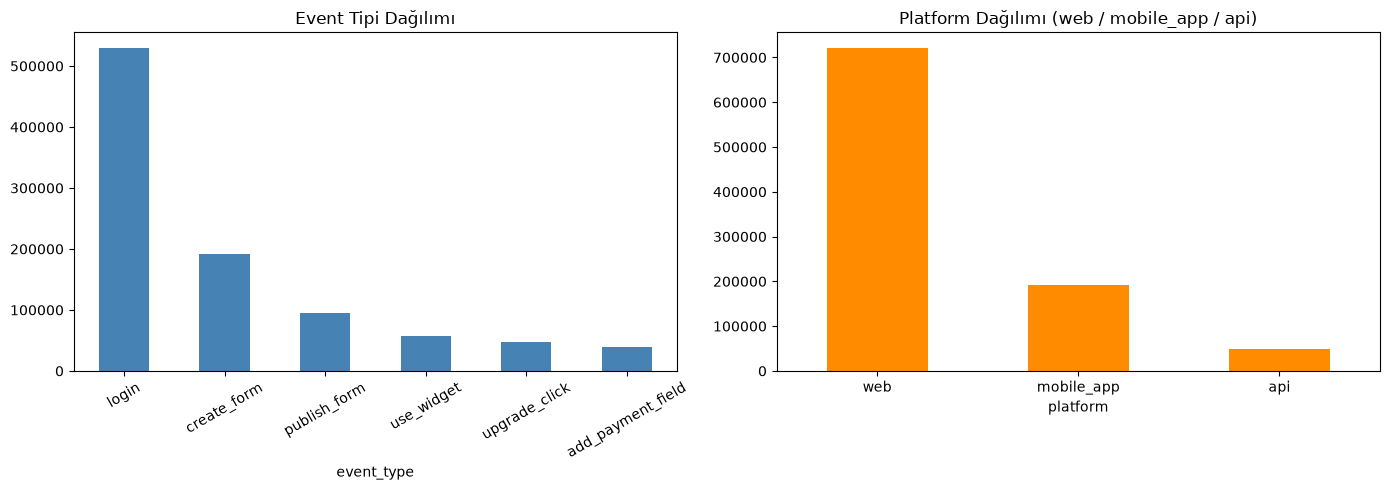

Kullanıcı başına event sayısı - özet istatistik:
count    119945.000000
mean          8.001284
std           2.835001
min           1.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          23.000000
dtype: float64


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

events['event_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Event Tipi Dağılımı')
axes[0].tick_params(axis='x', rotation=30)

events['platform'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Platform Dağılımı (web / mobile_app / api)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Kullanici basina ortalama event sayisi
events_per_user = events.groupby('user_id').size()
print("Kullanıcı başına event sayısı - özet istatistik:")
print(events_per_user.describe())

In [44]:
submissions = pd.read_sql("SELECT * FROM submissions", conn)

print("Boyut (satır, sütun):", submissions.shape)
print()
submissions.info()

Boyut (satır, sütun): (882603, 9)

<class 'pandas.DataFrame'>
RangeIndex: 882603 entries, 0 to 882602
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   submission_id        882603 non-null  int64  
 1   form_id              882603 non-null  int64  
 2   submitted_at         882603 non-null  str    
 3   device_type          882603 non-null  str    
 4   browser              882603 non-null  str    
 5   referrer_domain      882603 non-null  str    
 6   completion_time_sec  882603 non-null  float64
 7   is_partial           882603 non-null  int64  
 8   ip_hash              882603 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 60.6 MB


In [45]:
submissions['submitted_at'] = pd.to_datetime(submissions['submitted_at'])
submissions['is_partial'] = submissions['is_partial'].astype(bool)

In [46]:
print("Tekrar eden submission_id sayısı:", submissions['submission_id'].duplicated().sum())
print()

Tekrar eden submission_id sayısı: 0



In [47]:
# Her submission'in form_id'si, forms tablosunda gercekten var olmali
orphan_submissions = ~submissions['form_id'].isin(forms['form_id'])
print(f"forms tablosunda karsiligi olmayan submission sayısı: {orphan_submissions.sum()}")
print()

forms tablosunda karsiligi olmayan submission sayısı: 0



In [49]:
#Cok kısa tamamlanma sureleri (potansiyel bot/fraud)
very_fast = submissions[submissions['completion_time_sec'] < 5]
print(f"5 saniyeden kisa surede tamamlanan submission sayısı: {len(very_fast)} (%{100*len(very_fast)/len(submissions):.2f})")

5 saniyeden kisa surede tamamlanan submission sayısı: 28199 (%3.19)


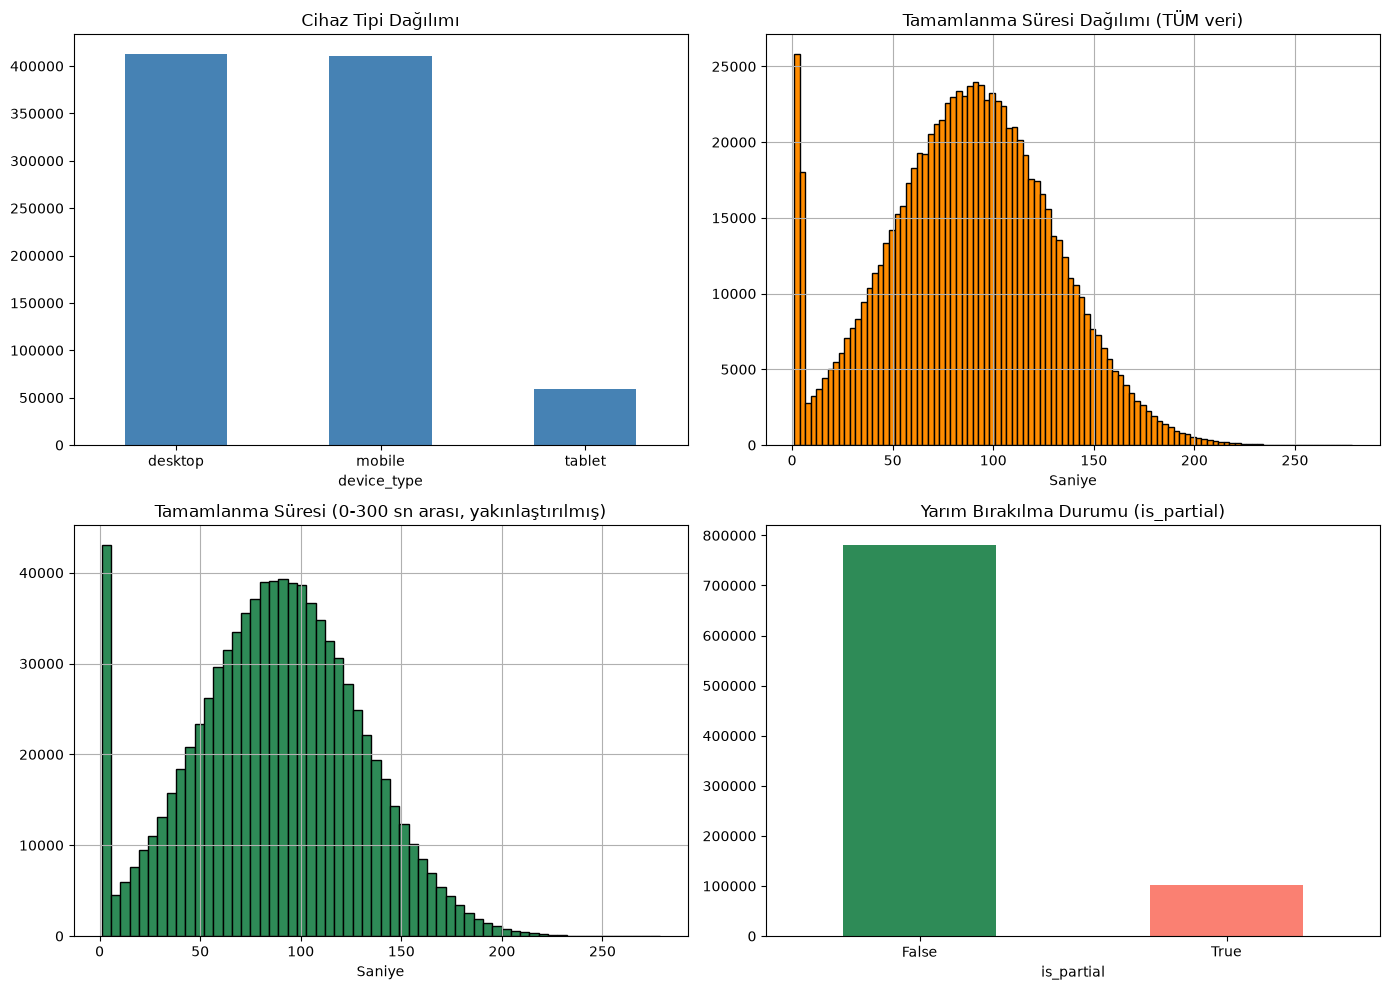

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

submissions['device_type'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Cihaz Tipi Dağılımı')
axes[0,0].tick_params(axis='x', rotation=0)

submissions['completion_time_sec'].hist(bins=100, ax=axes[0,1], color='darkorange', edgecolor='black')
axes[0,1].set_title('Tamamlanma Süresi Dağılımı (TÜM veri)')
axes[0,1].set_xlabel('Saniye')

# Sadece normal aralik (0-300 sn) - botlarin etkisini gormeden once
submissions[submissions['completion_time_sec'].between(0, 300)]['completion_time_sec'].hist(
    bins=60, ax=axes[1,0], color='seagreen', edgecolor='black')
axes[1,0].set_title('Tamamlanma Süresi (0-300 sn arası, yakınlaştırılmış)')
axes[1,0].set_xlabel('Saniye')

submissions['is_partial'].value_counts().plot(kind='bar', ax=axes[1,1], color=['seagreen','salmon'])
axes[1,1].set_title('Yarım Bırakılma Durumu (is_partial)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [51]:
# İkinci grafikte sıfır(0) civarında yükselen bir çubuk var, bot trafiğinin gözle görülür hali. Ve burada bimodal dağılım görüyoruz.


In [52]:
bot_like = submissions[submissions['completion_time_sec'] < 5]
print(f"5 saniyeden kısa: {len(bot_like):,} submission (%{100*len(bot_like)/len(submissions):.2f})")
print()
print("Bu şüpheli submission'ların hangi ip_hash'lerden geldiğine bakalım:")
print(bot_like['ip_hash'].value_counts().head())

5 saniyeden kısa: 28,199 submission (%3.19)

Bu şüpheli submission'ların hangi ip_hash'lerden geldiğine bakalım:
ip_hash
0b4499278d    28199
Name: count, dtype: int64


In [53]:
# 0b4499278d no'lu IP'nin tek bir kaynağın sistematik olarak birçok farklı formu hedef aldığının kesin kanıtı

In [54]:
support_tickets = pd.read_sql("SELECT * FROM support_tickets", conn)

print("Boyut (satır, sütun):", support_tickets.shape)
print()
support_tickets.info()

Boyut (satır, sütun): (75218, 8)

<class 'pandas.DataFrame'>
RangeIndex: 75218 entries, 0 to 75217
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              75218 non-null  int64  
 1   user_id                75218 non-null  int64  
 2   created_at             75218 non-null  str    
 3   category               75218 non-null  str    
 4   priority               75218 non-null  str    
 5   is_resolved            75218 non-null  int64  
 6   resolution_time_hours  51578 non-null  float64
 7   csat_score             51578 non-null  float64
dtypes: float64(2), int64(3), str(3)
memory usage: 4.6 MB


In [55]:
# resolution_time_hours ve csat_score yapısal olarak boş olması gerekiyor çünkü bir talep çözülmediyse,"çözülme süresi" veya "memnuniyet puanı" diye bir şey olamaz

In [56]:
support_tickets['created_at'] = pd.to_datetime(support_tickets['created_at'])
support_tickets['is_resolved'] = support_tickets['is_resolved'].astype(bool)


In [57]:
print("Tekrar eden ticket_id sayısı:", support_tickets['ticket_id'].duplicated().sum())
print()

Tekrar eden ticket_id sayısı: 0



In [58]:
for col in ['category', 'priority']:
    print(f"--- {col} ---")
    print(support_tickets[col].value_counts())
    print()

--- category ---
category
technical          20943
billing            16694
feature_request    13463
bug_report         11247
account_access      7602
other               5269
Name: count, dtype: int64

--- priority ---
priority
low       37583
medium    26409
high      11226
Name: count, dtype: int64



In [59]:
print(f"Genel çözülme oranı: %{100*support_tickets['is_resolved'].mean():.1f}")
print(f"Ortalama CSAT (sadece çözülenler): {support_tickets['csat_score'].mean():.2f}")

Genel çözülme oranı: %68.6
Ortalama CSAT (sadece çözülenler): 3.83


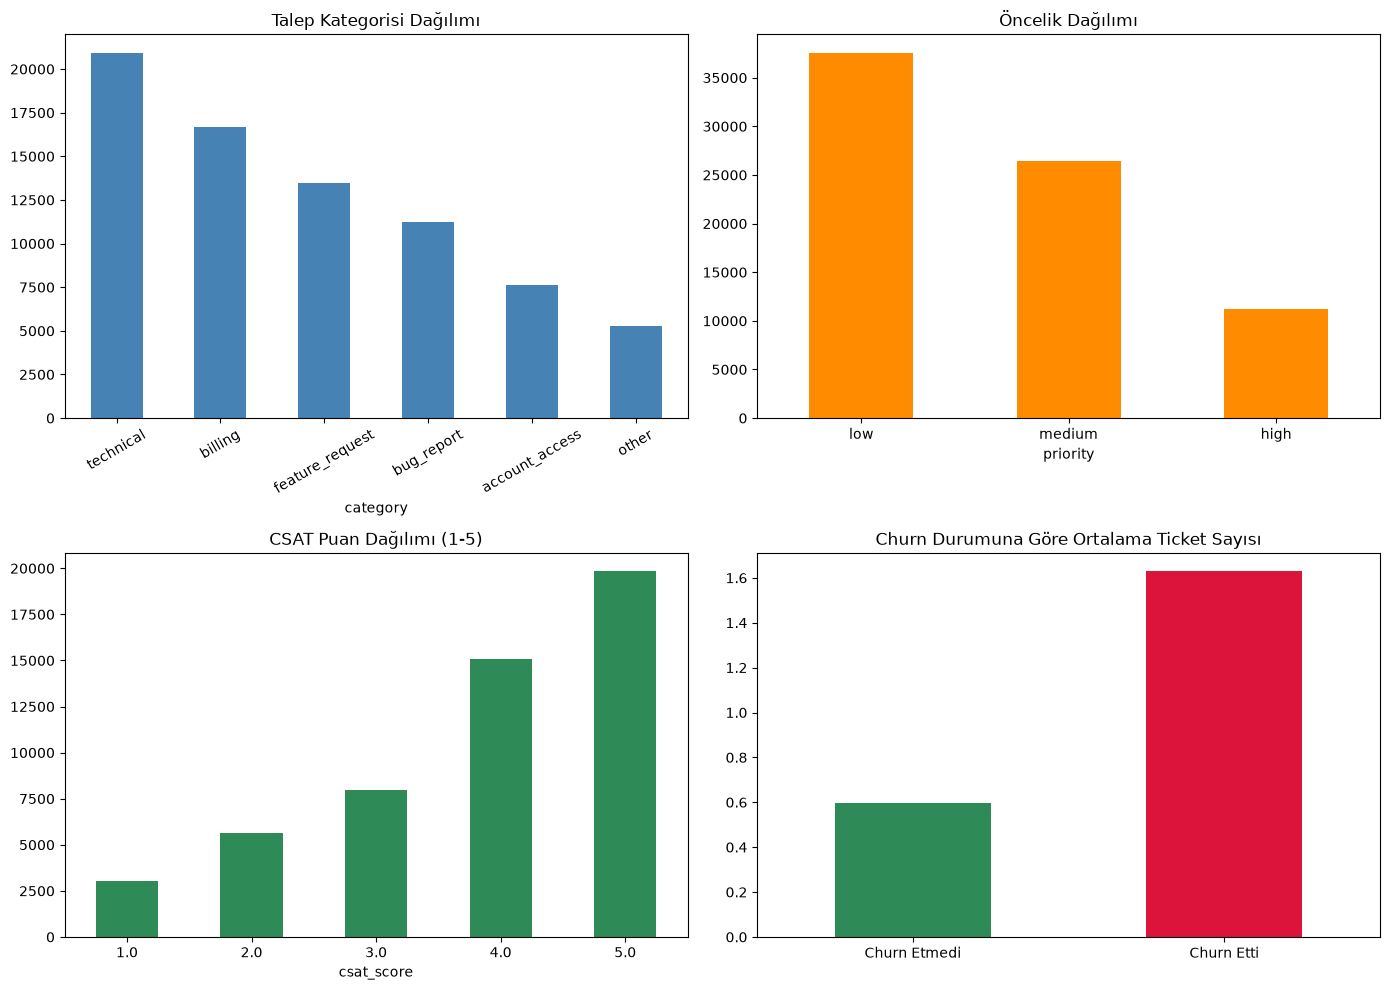

Churn Etmedi    0.598051
Churn Etti      1.628414
Name: ticket_count, dtype: float64


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

support_tickets['category'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Talep Kategorisi Dağılımı')
axes[0,0].tick_params(axis='x', rotation=30)

support_tickets['priority'].value_counts().plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Öncelik Dağılımı')
axes[0,1].tick_params(axis='x', rotation=0)

support_tickets['csat_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('CSAT Puan Dağılımı (1-5)')
axes[1,0].tick_params(axis='x', rotation=0)

# ASIL ONEMLI GRAFIK: churn ile ticket sayisi iliskisi
ticket_counts = support_tickets.groupby('user_id').size().reset_index(name='ticket_count')
merged = subscriptions[subscriptions['plan'] != 'free'][['user_id', 'is_churned']].merge(
    ticket_counts, on='user_id', how='left')
merged['ticket_count'] = merged['ticket_count'].fillna(0)

avg_tickets = merged.groupby('is_churned')['ticket_count'].mean()
avg_tickets.index = ['Churn Etmedi', 'Churn Etti']
avg_tickets.plot(kind='bar', ax=axes[1,1], color=['seagreen', 'crimson'])
axes[1,1].set_title('Churn Durumuna Göre Ortalama Ticket Sayısı')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(avg_tickets)

In [61]:
marketing_spend = pd.read_sql("SELECT * FROM marketing_spend", conn)

print("Boyut (satır, sütun):", marketing_spend.shape)
print()
marketing_spend.info()
print()
marketing_spend.head(10)

Boyut (satır, sütun): (120, 6)

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   channel             120 non-null    str    
 1   month               120 non-null    str    
 2   spend_usd           120 non-null    float64
 3   impressions         120 non-null    int64  
 4   clicks              120 non-null    int64  
 5   attributed_signups  120 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 5.8 KB



,channel,month,spend_usd,impressions,clicks,attributed_signups
0,paid_search,2023-01,26942.67,1386326,31034,1165
1,paid_social,2023-01,11353.52,672067,18403,1048
2,content_marketing,2023-01,4257.08,200205,4076,790
3,organic_search,2023-01,0.00,0,0,1519
4,referral,2023-01,0.00,0,0,637
5,paid_search,2023-02,24724.22,1003001,20915,952
6,paid_social,2023-02,10790.19,577694,19162,886
7,content_marketing,2023-02,4291.37,189345,5007,668
8,organic_search,2023-02,0.00,0,0,1411
9,referral,2023-02,0.00,0,0,572


In [62]:
marketing_spend['month'] = pd.to_datetime(marketing_spend['month'])
dup_check = marketing_spend.duplicated(subset=['channel', 'month']).sum()
print("Tekrar eden (kanal, ay) kombinasyonu sayısı:", dup_check)
print()

Tekrar eden (kanal, ay) kombinasyonu sayısı: 0



In [64]:
#Feature Engineering
marketing_spend['ctr_pct'] = np.where(
    marketing_spend['impressions'] > 0,
    100 * marketing_spend['clicks'] / marketing_spend['impressions'],
    np.nan
)
marketing_spend['cpc_usd'] = np.where(
    marketing_spend['clicks'] > 0,
    marketing_spend['spend_usd'] / marketing_spend['clicks'],
    np.nan
)
marketing_spend['cac_usd'] = np.where(
    marketing_spend['attributed_signups'] > 0,
    marketing_spend['spend_usd'] / marketing_spend['attributed_signups'],
    np.nan
)


In [66]:
channel_summary = marketing_spend.groupby('channel').agg(
    total_spend=('spend_usd', 'sum'),
    total_signups=('attributed_signups', 'sum'),
    avg_ctr_pct=('ctr_pct', 'mean'),
    avg_cpc_usd=('cpc_usd', 'mean')
).round(2)

In [67]:
ab_test = pd.read_sql("SELECT * FROM ab_test_assignments", conn)

print("Boyut (satır, sütun):", ab_test.shape)
print()
ab_test.info()
print()

Boyut (satır, sütun): (7418, 3)

<class 'pandas.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      7418 non-null   int64
 1   variant      7418 non-null   str  
 2   assigned_at  7418 non-null   str  
dtypes: int64(1), str(2)
memory usage: 174.0 KB



In [68]:
ab_test['assigned_at'] = pd.to_datetime(ab_test['assigned_at'])

In [69]:
print(ab_test['variant'].value_counts())
print()
print("Oranlar:")
print(ab_test['variant'].value_counts(normalize=True).round(3))

variant
control      3746
treatment    3672
Name: count, dtype: int64

Oranlar:
variant
control      0.505
treatment    0.495
Name: proportion, dtype: float64
